# Logistic Regression From Scratch — Binary Classification

In this notebook we build a **Logistic Regression classifier completely from scratch** using only NumPy. No scikit-learn for modeling — just pure math and code.

We apply it to a **synthetic email spam detection** dataset: given two features extracted from an email, predict whether it is spam (1) or not spam (0).

---

## Table of Contents

1. [Why Not Linear Regression for Classification?](#1)
2. [The Logistic / Sigmoid Function](#2)
3. [Generating the Spam Dataset](#3)
4. [The Math in Brief](#4)
5. [Implementing the Model](#5)
6. [Training the Model](#6)
7. [Visualizing Training — Cost Curve](#7)
8. [Decision Boundary](#8)
9. [Evaluating the Model](#9)
10. [ROC Curve and AUC](#10)
11. [Precision-Recall Curve](#11)

---

## 1. Why Not Linear Regression for Classification?

Linear regression predicts a continuous number like 3500 or 9.7. For binary classification we need an output **between 0 and 1** — a probability.

If we forced linear regression onto a classification problem:
- Predictions could go below 0 or above 1, which makes no sense as probabilities.
- The decision threshold would be arbitrary and unstable.

Logistic regression solves this by passing the linear output through a **sigmoid function** that squashes any real number into (0, 1).

---

## 2. The Logistic / Sigmoid Function

The sigmoid function is defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- When $z \to +\infty$, $\sigma(z) \to 1$
- When $z \to -\infty$, $\sigma(z) \to 0$
- When $z = 0$, $\sigma(z) = 0.5$

We interpret $\sigma(z)$ as the **probability that the input belongs to class 1** (spam).

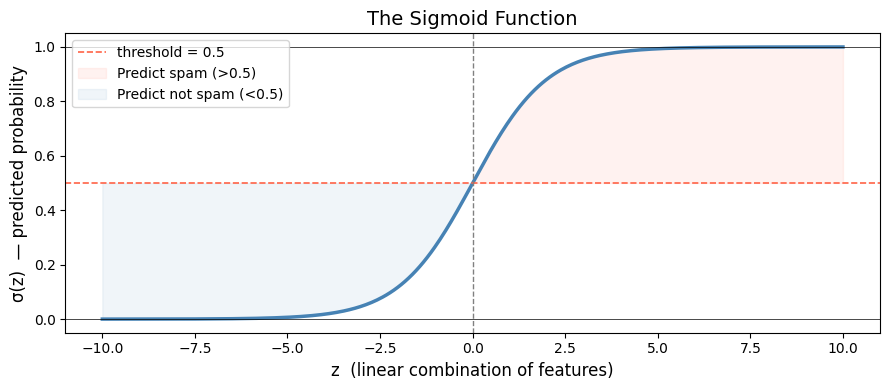

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

# --- Plot the sigmoid function ---
z = np.linspace(-10, 10, 400)
sigmoid_z = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, sigmoid_z, color='steelblue', linewidth=2.5)
ax.axhline(0.5, color='tomato',   linestyle='--', linewidth=1.2, label='threshold = 0.5')
ax.axvline(0.0, color='gray',     linestyle='--', linewidth=1.0)
ax.axhline(0.0, color='black',    linewidth=0.5)
ax.axhline(1.0, color='black',    linewidth=0.5)
ax.fill_between(z, sigmoid_z, 0.5, where=(sigmoid_z > 0.5),
                alpha=0.08, color='tomato', label='Predict spam (>0.5)')
ax.fill_between(z, sigmoid_z, 0.5, where=(sigmoid_z < 0.5),
                alpha=0.08, color='steelblue', label='Predict not spam (<0.5)')
ax.set_xlabel('z  (linear combination of features)', fontsize=12)
ax.set_ylabel('σ(z)  — predicted probability', fontsize=12)
ax.set_title('The Sigmoid Function', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

---

## 3. Generating the Spam Dataset

We simulate two features extracted from emails:

- **Feature 1 — `spam_word_count`**: number of spam-trigger words (e.g. "free", "winner", "click") per email
- **Feature 2 — `link_count`**: number of hyperlinks in the email

Spam emails (label = 1) tend to have more spam words and more links than legitimate emails (label = 0).

In [2]:
N = 600   # total emails

# --- Class 0: Legitimate emails ---
n0 = N // 2
X0 = np.column_stack([
    np.random.normal(2.0, 1.2, n0),   # spam_word_count  (low)
    np.random.normal(1.5, 1.0, n0),   # link_count        (low)
])
y0 = np.zeros(n0)

# --- Class 1: Spam emails ---
n1 = N // 2
X1 = np.column_stack([
    np.random.normal(6.5, 1.5, n1),   # spam_word_count  (high)
    np.random.normal(5.5, 1.2, n1),   # link_count        (high)
])
y1 = np.ones(n1)

# Stack and shuffle
X_raw = np.vstack([X0, X1])
y     = np.hstack([y0, y1])

shuffle_idx = np.random.permutation(N)
X_raw, y    = X_raw[shuffle_idx], y[shuffle_idx]

print(f"Dataset shape : X={X_raw.shape}, y={y.shape}")
print(f"Spam emails   : {int(y.sum())}  ({y.mean()*100:.1f}%)")
print(f"Legit emails  : {int((1-y).sum())}  ({(1-y).mean()*100:.1f}%)")

Dataset shape : X=(600, 2), y=(600,)
Spam emails   : 300  (50.0%)
Legit emails  : 300  (50.0%)


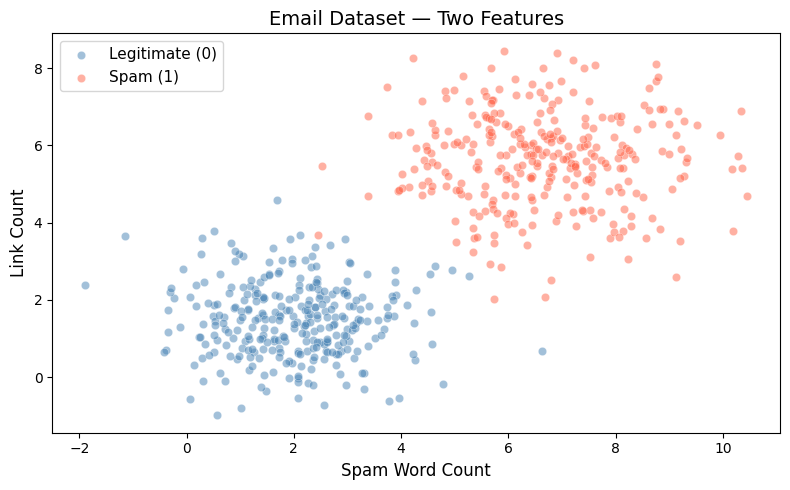

In [3]:
# --- Scatter plot of the raw data ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(X_raw[y==0, 0], X_raw[y==0, 1],
           color='steelblue', alpha=0.5, edgecolors='white',
           linewidths=0.4, label='Legitimate (0)')
ax.scatter(X_raw[y==1, 0], X_raw[y==1, 1],
           color='tomato', alpha=0.5, edgecolors='white',
           linewidths=0.4, label='Spam (1)')

ax.set_xlabel('Spam Word Count', fontsize=12)
ax.set_ylabel('Link Count', fontsize=12)
ax.set_title('Email Dataset — Two Features', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## 4. The Math in Brief

### Prediction

$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

### Cost Function — Binary Cross-Entropy

We cannot use MSE for logistic regression (it produces a non-convex surface). Instead we use **Binary Cross-Entropy (Log Loss)**:

$$J(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Gradients (for gradient descent)

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{N} \mathbf{X}^T (\hat{y} - y) \qquad \frac{\partial J}{\partial b} = \frac{1}{N} \sum (\hat{y}_i - y_i)$$

These have the same form as linear regression — only the prediction step differs.

---

## 5. Implementing the Model

We build a `LogisticRegressionNumPy` class with:
- `fit(X, y)` — trains with gradient descent
- `predict_proba(X)` — returns probabilities
- `predict(X)` — returns binary class labels (0 or 1)
- `score(X, y)` — returns accuracy

In [4]:
class LogisticRegressionNumPy:
    """
    Binary logistic regression trained with gradient descent.

    Parameters
    ----------
    learning_rate : float  — step size per gradient update
    n_iterations  : int    — number of gradient descent steps
    threshold     : float  — probability cutoff for class 1 prediction
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iterations  = n_iterations
        self.threshold     = threshold
        self.weights       = None   # shape: (n_features,)
        self.bias          = 0.0
        self.cost_history  = []

    # ------------------------------------------------------------------
    # Sigmoid activation
    # ------------------------------------------------------------------
    def _sigmoid(self, z):
        # Clip z to avoid overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    # ------------------------------------------------------------------
    # Binary cross-entropy cost
    # ------------------------------------------------------------------
    def _compute_cost(self, y_hat, y):
        N = len(y)
        # Small epsilon to prevent log(0)
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        cost  = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return cost

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    def fit(self, X, y, verbose=True):
        N, n_features   = X.shape
        self.weights    = np.zeros(n_features)
        self.bias       = 0.0
        self.cost_history = []

        for i in range(self.n_iterations):

            # Forward pass
            z     = X @ self.weights + self.bias   # linear combination
            y_hat = self._sigmoid(z)               # probabilities

            # Cost
            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)

            # Gradients
            error = y_hat - y                              # (N,)
            dw    = (1 / N) * (X.T @ error)               # (n_features,)
            db    = (1 / N) * np.sum(error)               # scalar

            # Parameter update
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            if verbose and (i % 200 == 0 or i == self.n_iterations - 1):
                print(f"Iter {i:>5d} | Cost: {cost:.6f}")

        return self

    # ------------------------------------------------------------------
    # Predict probability of class 1
    # ------------------------------------------------------------------
    def predict_proba(self, X):
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    # ------------------------------------------------------------------
    # Predict binary labels
    # ------------------------------------------------------------------
    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)

    # ------------------------------------------------------------------
    # Accuracy score
    # ------------------------------------------------------------------
    def score(self, X, y):
        return np.mean(self.predict(X) == y)


print("LogisticRegressionNumPy class defined.")

LogisticRegressionNumPy class defined.


---

## 6. Training the Model

### 6.1 Train / Test Split

In [5]:
split     = int(0.8 * N)
idx       = np.random.permutation(N)
train_idx = idx[:split]
test_idx  = idx[split:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train,     y_test     = y[train_idx],     y[test_idx]

print(f"Train: {X_train_raw.shape[0]} samples | Test: {X_test_raw.shape[0]} samples")

Train: 480 samples | Test: 120 samples


### 6.2 Feature Standardization

We apply **Z-score standardization** so each feature has mean 0 and std 1:

$$X_{\text{std}} = \frac{X - \mu}{\sigma}$$

This prevents one feature from dominating gradient updates due to scale differences.

In [6]:
mu    = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw  - mu) / sigma

print(f"Train mean (should be ~0): {X_train.mean(axis=0).round(4)}")
print(f"Train std  (should be ~1): {X_train.std(axis=0).round(4)}")

Train mean (should be ~0): [-0. -0.]
Train std  (should be ~1): [1. 1.]


### 6.3 Fit

In [7]:
model = LogisticRegressionNumPy(learning_rate=0.5, n_iterations=1000)
model.fit(X_train, y_train)

print(f"\nLearned weights : {model.weights.round(4)}")
print(f"Learned bias    : {model.bias:.4f}")

Iter     0 | Cost: 0.693147
Iter   200 | Cost: 0.031130
Iter   400 | Cost: 0.024090
Iter   600 | Cost: 0.021361
Iter   800 | Cost: 0.019871
Iter   999 | Cost: 0.018923

Learned weights : [4.143 4.805]
Learned bias    : 0.6356


---

## 7. Visualizing Training — Cost Curve

The binary cross-entropy cost should decrease smoothly and flatten as the model converges.

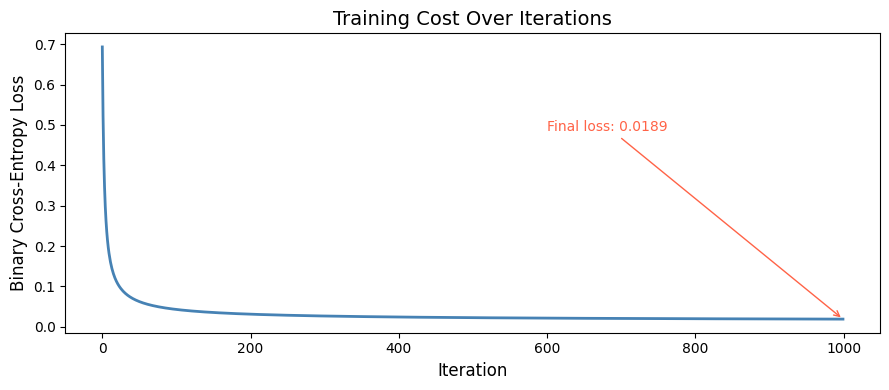

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.cost_history, color='steelblue', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Cost Over Iterations', fontsize=14)
ax.annotate(f"Final loss: {model.cost_history[-1]:.4f}",
            xy=(len(model.cost_history)-1, model.cost_history[-1]),
            xytext=(len(model.cost_history)*0.6, model.cost_history[0]*0.7),
            arrowprops=dict(arrowstyle='->', color='tomato'),
            fontsize=10, color='tomato')
plt.tight_layout()
plt.show()

---

## 8. Decision Boundary

The decision boundary is the line where $P(\text{spam}) = 0.5$, i.e. $\mathbf{w}^T \mathbf{x} + b = 0$.

On one side the model predicts spam; on the other, legitimate.

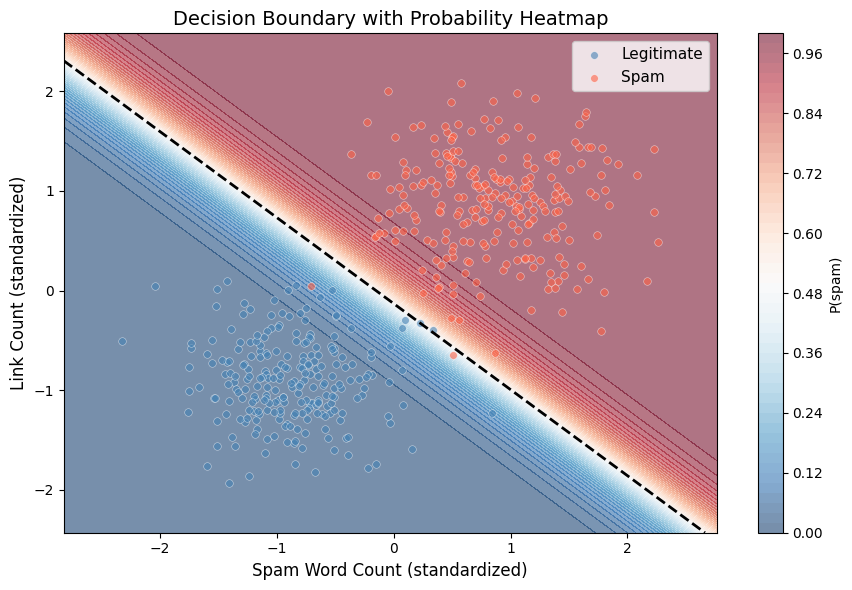

In [9]:
# Build a grid over the standardized feature space
x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                       np.linspace(x2_min, x2_max, 300))
grid      = np.column_stack([xx1.ravel(), xx2.ravel()])
Z         = model.predict_proba(grid).reshape(xx1.shape)

fig, ax = plt.subplots(figsize=(9, 6))

# Probability heatmap
cf = ax.contourf(xx1, xx2, Z, levels=50,
                 cmap='RdBu_r', alpha=0.55, vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='P(spam)')

# Decision boundary at 0.5
ax.contour(xx1, xx2, Z, levels=[0.5],
           colors='black', linewidths=2, linestyles='--')

# Training points
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           color='steelblue', alpha=0.6, edgecolors='white',
           linewidths=0.4, label='Legitimate', s=30)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           color='tomato', alpha=0.6, edgecolors='white',
           linewidths=0.4, label='Spam', s=30)

ax.set_xlabel('Spam Word Count (standardized)', fontsize=12)
ax.set_ylabel('Link Count (standardized)', fontsize=12)
ax.set_title('Decision Boundary with Probability Heatmap', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## 9. Evaluating the Model

### 9.1 Classification Metrics

For binary classification we go beyond accuracy. Four key values come from the **confusion matrix**:

| | Predicted Spam | Predicted Legit |
|---|---|---|
| **Actual Spam** | True Positive (TP) | False Negative (FN) |
| **Actual Legit** | False Positive (FP) | True Negative (TN) |

From these we derive:

$$\text{Accuracy} = \frac{TP + TN}{N} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F1 = \frac{2 \cdot P \cdot R}{P + R}$$

In [10]:
def confusion_matrix_scratch(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[TN, FP], [FN, TP]])

def classification_report_scratch(y_true, y_pred):
    cm        = confusion_matrix_scratch(y_true, y_pred)
    TN, FP    = cm[0]
    FN, TP    = cm[1]
    accuracy  = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-15)
    recall    = TP / (TP + FN + 1e-15)
    f1        = 2 * precision * recall / (precision + recall + 1e-15)
    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'cm': cm}

y_pred_test = model.predict(X_test)
report      = classification_report_scratch(y_test, y_pred_test)

print("--- Test Set Classification Report ---")
print(f"Accuracy  : {report['accuracy']:.4f}")
print(f"Precision : {report['precision']:.4f}")
print(f"Recall    : {report['recall']:.4f}")
print(f"F1 Score  : {report['f1']:.4f}")

--- Test Set Classification Report ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


### 9.2 Confusion Matrix Heatmap

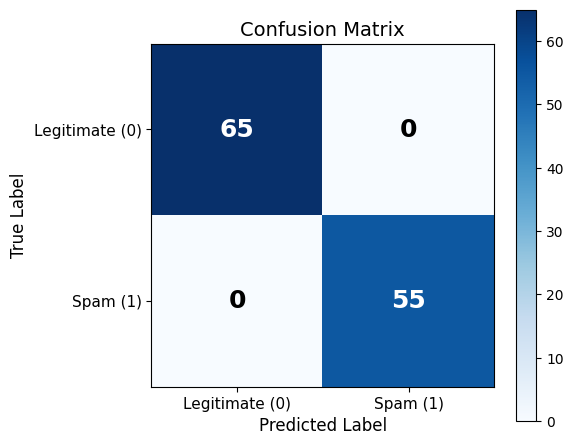

In [11]:
cm     = report['cm']
labels = ['Legitimate (0)', 'Spam (1)']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > thresh else 'black'
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=18,
                fontweight='bold', color=color)

plt.tight_layout()
plt.show()

---

## 10. ROC Curve and AUC

The **ROC (Receiver Operating Characteristic)** curve shows how the **True Positive Rate** and **False Positive Rate** trade off as we vary the classification threshold.

- **TPR (Recall)** = $\frac{TP}{TP + FN}$ — what fraction of actual spam did we catch?
- **FPR** = $\frac{FP}{FP + TN}$ — what fraction of legit emails did we wrongly flag?

**AUC (Area Under Curve)** summarizes performance in a single number:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random guessing

C:\Users\payfi\AppData\Local\Temp\ipykernel_3024\2649927658.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr[sorted_idx], fpr[sorted_idx])


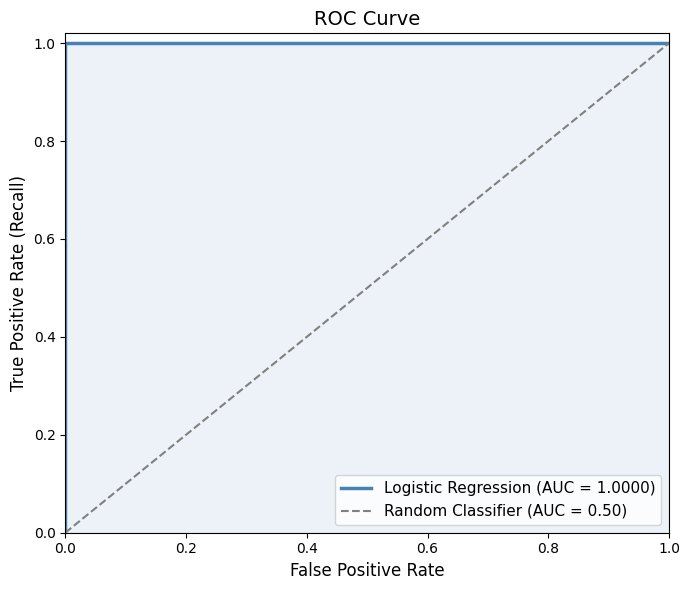

AUC = 1.0000


In [12]:
def roc_curve_scratch(y_true, y_scores):
    thresholds = np.linspace(0, 1, 300)
    tprs, fprs = [], []
    for t in thresholds:
        y_p  = (y_scores >= t).astype(int)
        TP   = np.sum((y_p == 1) & (y_true == 1))
        FN   = np.sum((y_p == 0) & (y_true == 1))
        FP   = np.sum((y_p == 1) & (y_true == 0))
        TN   = np.sum((y_p == 0) & (y_true == 0))
        tprs.append(TP / (TP + FN + 1e-15))
        fprs.append(FP / (FP + TN + 1e-15))
    return np.array(fprs), np.array(tprs), thresholds

def auc_trapezoidal(fpr, tpr):
    sorted_idx = np.argsort(fpr)
    return np.trapz(tpr[sorted_idx], fpr[sorted_idx])

y_scores        = model.predict_proba(X_test)
fpr, tpr, thres = roc_curve_scratch(y_test, y_scores)
auc             = auc_trapezoidal(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.10, color='steelblue')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.4f}")

---

## 11. Precision-Recall Curve

The **Precision-Recall (PR) curve** is more informative than the ROC curve when classes are **imbalanced** (e.g. very few spam emails).

- High **precision** = when we flag spam, we are usually right
- High **recall** = we catch most of the actual spam

The two metrics trade off against each other. The **Average Precision (AP)** is the area under the PR curve — higher is better.

C:\Users\payfi\AppData\Local\Temp\ipykernel_3024\453396675.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_precision       = np.trapz(precisions[np.argsort(recalls)],


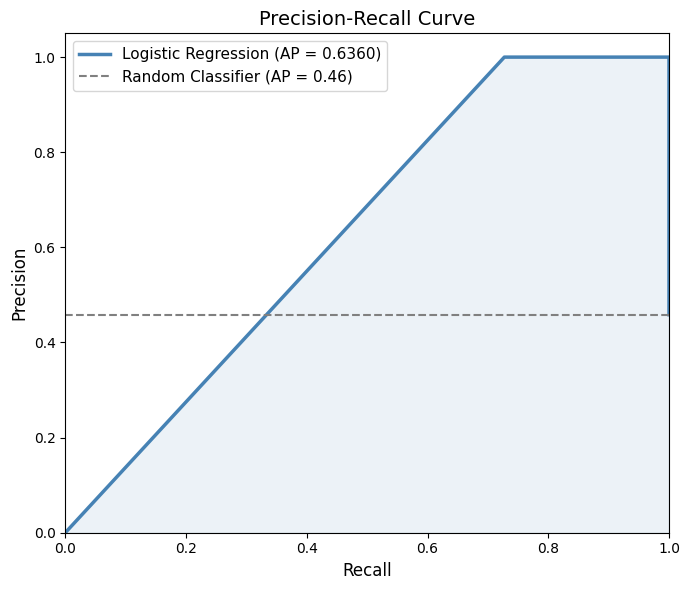

Average Precision = 0.6360


In [13]:
def pr_curve_scratch(y_true, y_scores):
    thresholds  = np.linspace(0, 1, 300)
    precisions  = []
    recalls     = []
    for t in thresholds:
        y_p  = (y_scores >= t).astype(int)
        TP   = np.sum((y_p == 1) & (y_true == 1))
        FP   = np.sum((y_p == 1) & (y_true == 0))
        FN   = np.sum((y_p == 0) & (y_true == 1))
        precisions.append(TP / (TP + FP + 1e-15))
        recalls.append(TP / (TP + FN + 1e-15))
    return np.array(recalls), np.array(precisions)

recalls, precisions = pr_curve_scratch(y_test, y_scores)
avg_precision       = np.trapz(precisions[np.argsort(recalls)],
                               recalls[np.argsort(recalls)])

# Baseline: fraction of positives (random classifier)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls, precisions, color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AP = {avg_precision:.4f})')
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
           label=f'Random Classifier (AP = {baseline:.2f})')
ax.fill_between(recalls, precisions, alpha=0.10, color='steelblue')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"Average Precision = {avg_precision:.4f}")